# Laboratorio 3 – Modelos de Regresión Lineal
## CC3074 – Minería de Datos | Semestre I – 2026
### InmoValor S.A. – Predicción de precios de viviendas

**Dataset:** House Prices: Advanced Regression Techniques (Kaggle)

**Objetivo:** Desarrollar modelos de regresión lineal para predecir el precio de venta (`SalePrice`) de viviendas en Ames, Iowa, a partir de 79 variables explicativas que describen aspectos como calidad, tamaño, ubicación y condición de las propiedades.

---

## 1. Importación de Librerías y Carga de Datos

In [11]:
%pip install -q pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.



In [12]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, skew, kurtosis

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 85)
pd.set_option('display.max_rows', 100)
import warnings
warnings.filterwarnings('ignore')

print("Librerias importadas correctamente")

Librerias importadas correctamente


In [13]:
# Carga de datos
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Dataset de entrenamiento: {train.shape[0]} filas x {train.shape[1]} columnas")
print(f"Dataset de prueba: {test.shape[0]} filas x {test.shape[1]} columnas")
print(f"\nVariable objetivo: SalePrice")
print(f"   - Presente en train: {'SalePrice' in train.columns}")
print(f"   - Presente en test: {'SalePrice' in test.columns}")

Dataset de entrenamiento: 1460 filas x 81 columnas
Dataset de prueba: 1459 filas x 80 columnas

Variable objetivo: SalePrice
   - Presente en train: True
   - Presente en test: False


## 2. Descripción de las Variables

El dataset contiene **81 variables** (incluyendo `Id` y `SalePrice`). Las variables se pueden categorizar en los siguientes grupos temáticos:

| Categoría | Variables | Descripción |
|---|---|---|
| **Identificación** | `Id` | Identificador único de la propiedad |
| **Tipo de vivienda** | `MSSubClass`, `BldgType`, `HouseStyle` | Clasificación del tipo de construcción y estilo |
| **Zonificación y terreno** | `MSZoning`, `LotFrontage`, `LotArea`, `LotShape`, `LandContour`, `LotConfig`, `LandSlope` | Características del terreno y zonificación |
| **Acceso e infraestructura** | `Street`, `Alley`, `Utilities`, `PavedDrive` | Tipo de acceso y servicios disponibles |
| **Ubicación** | `Neighborhood`, `Condition1`, `Condition2` | Vecindario y proximidad a características |
| **Calidad general** | `OverallQual`, `OverallCond` | Calificación general de calidad y condición (1-10) |
| **Antigüedad** | `YearBuilt`, `YearRemodAdd` | Año de construcción y remodelación |
| **Techo** | `RoofStyle`, `RoofMatl` | Estilo y material del techo |
| **Exterior** | `Exterior1st`, `Exterior2nd`, `MasVnrType`, `MasVnrArea`, `ExterQual`, `ExterCond` | Materiales y calidad exterior |
| **Cimentación y sótano** | `Foundation`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinSF1`, `BsmtFinType2`, `BsmtFinSF2`, `BsmtUnfSF`, `TotalBsmtSF` | Características del sótano |
| **Calefacción y aire** | `Heating`, `HeatingQC`, `CentralAir` | Sistema de calefacción y aire acondicionado |
| **Eléctrico** | `Electrical` | Sistema eléctrico |
| **Superficie habitable** | `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF`, `GrLivArea` | Pies cuadrados por nivel |
| **Baños** | `BsmtFullBath`, `BsmtHalfBath`, `FullBath`, `HalfBath` | Cantidad de baños |
| **Habitaciones** | `BedroomAbvGr`, `KitchenAbvGr`, `KitchenQual`, `TotRmsAbvGrd` | Habitaciones sobre nivel |
| **Funcionalidad** | `Functional` | Funcionalidad de la vivienda |
| **Chimenea** | `Fireplaces`, `FireplaceQu` | Número y calidad de chimeneas |
| **Garaje** | `GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageCars`, `GarageArea`, `GarageQual`, `GarageCond` | Características del garaje |
| **Áreas exteriores** | `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`, `3SsnPorch`, `ScreenPorch` | Porches y áreas exteriores |
| **Piscina** | `PoolArea`, `PoolQC` | Área y calidad de piscina |
| **Otros** | `Fence`, `MiscFeature`, `MiscVal` | Cerca, características misceláneas |
| **Venta** | `MoSold`, `YrSold`, `SaleType`, `SaleCondition` | Información de la venta |
| **Variable objetivo** | `SalePrice` | **Precio de venta de la vivienda (USD)** |

In [14]:
# Vista general del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO")
print("=" * 80)
print(f"\nDimensiones: {train.shape}")
print(f"\nPrimeras 5 filas:")
train.head()

INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO

Dimensiones: (1460, 81)

Primeras 5 filas:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [15]:
# Clasificación de variables por tipo
numericas = train.select_dtypes(include=[np.number]).columns.tolist()
categoricas = train.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas ({len(numericas)}):")
print(f"   {numericas}\n")
print(f"Variables categóricas ({len(categoricas)}):")
print(f"   {categoricas}\n")

# Información detallada de tipos de datos
print("=" * 80)
print("TIPOS DE DATOS Y VALORES NO NULOS")
print("=" * 80)
train.info()

Variables numéricas (38):
   ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Variables categóricas (43):
   ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Fu

In [16]:
# Estadísticas descriptivas de variables numéricas
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)
train[numericas].describe().T.round(2)

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.50,421.61,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.90,42.30,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.05,24.28,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.10,1.38,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.58,1.11,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0


### 2.1 Análisis de Valores Faltantes

Un paso crucial en la exploración es identificar qué variables tienen datos faltantes, cuántos y por qué. En este dataset, muchos valores `NaN` en realidad significan "no aplica" (por ejemplo, `PoolQC = NaN` significa que no hay piscina).

Variables con valores faltantes: 19 de 81
Variables sin valores faltantes: 62



,Valores Faltantes,Porcentaje (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


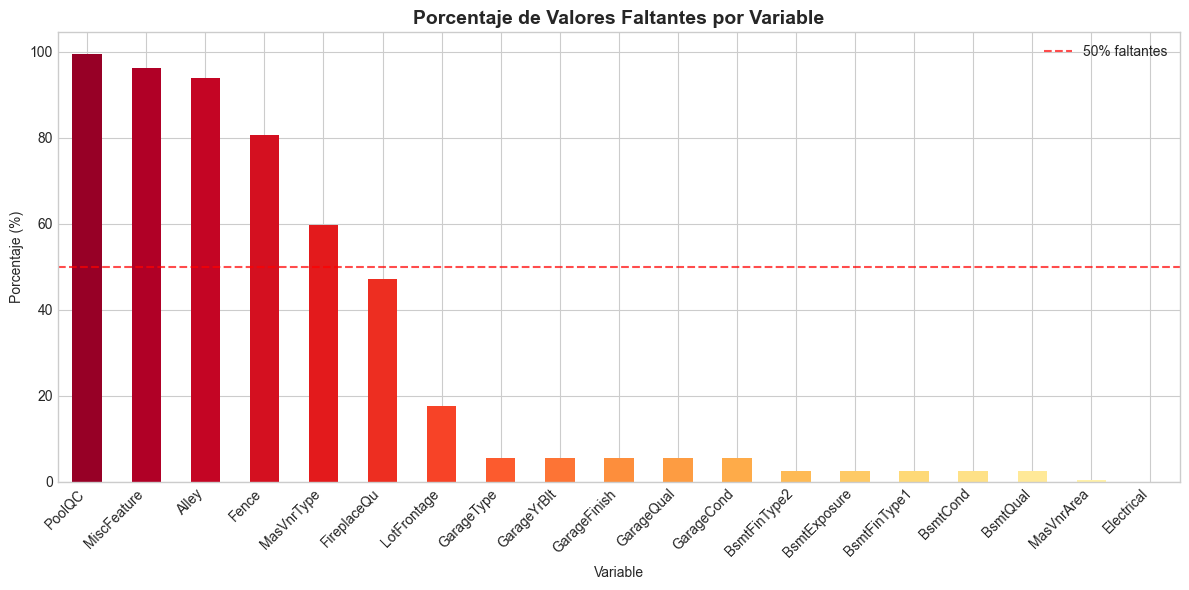

In [17]:
# Análisis de valores faltantes
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    'Valores Faltantes': missing,
    'Porcentaje (%)': missing_pct
})

print(f"Variables con valores faltantes: {len(missing_df)} de {train.shape[1]}")
print(f"Variables sin valores faltantes: {train.shape[1] - len(missing_df)}\n")
display(missing_df)

# Visualización de valores faltantes
fig, ax = plt.subplots(figsize=(12, 6))
missing_pct.plot(kind='bar', color=sns.color_palette("YlOrRd_r", len(missing_pct)), ax=ax)
ax.set_title('Porcentaje de Valores Faltantes por Variable', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.set_xlabel('Variable')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% faltantes')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Hallazgos sobre valores faltantes:**

- **PoolQC (99.5%), MiscFeature (96.3%), Alley (93.8%), Fence (80.8%):** Estos altos porcentajes no son realmente "datos perdidos". Significan que la mayoría de casas no tienen piscina, característica miscelánea, acceso por callejón, o cerca. Son informativos y se codificarán como "None".
- **FireplaceQu (47.3%):** Casas sin chimenea. Se codificará como "None".
- **Variables de garaje (~5.5%):** `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `GarageYrBlt` — casas sin garaje.
- **Variables de sótano (~2.5%):** `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` — casas sin sótano.
- **LotFrontage (17.7%):** Este sí es un dato faltante real. Se imputará con la mediana del vecindario.
- **MasVnrType y MasVnrArea (~0.5%):** Pocas observaciones, se imputarán.
- **Electrical (0.07%):** Un solo valor faltante, se imputará con la moda.

## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Distribución de la Variable Objetivo: `SalePrice`

**Pregunta:** ¿Cómo se distribuye el precio de venta? ¿Es simétrica o sesgada? ¿Hay outliers?

Comprender la distribución de `SalePrice` es fundamental ya que la regresión lineal asume normalidad en los residuos. Una variable objetivo muy sesgada puede afectar el rendimiento del modelo.

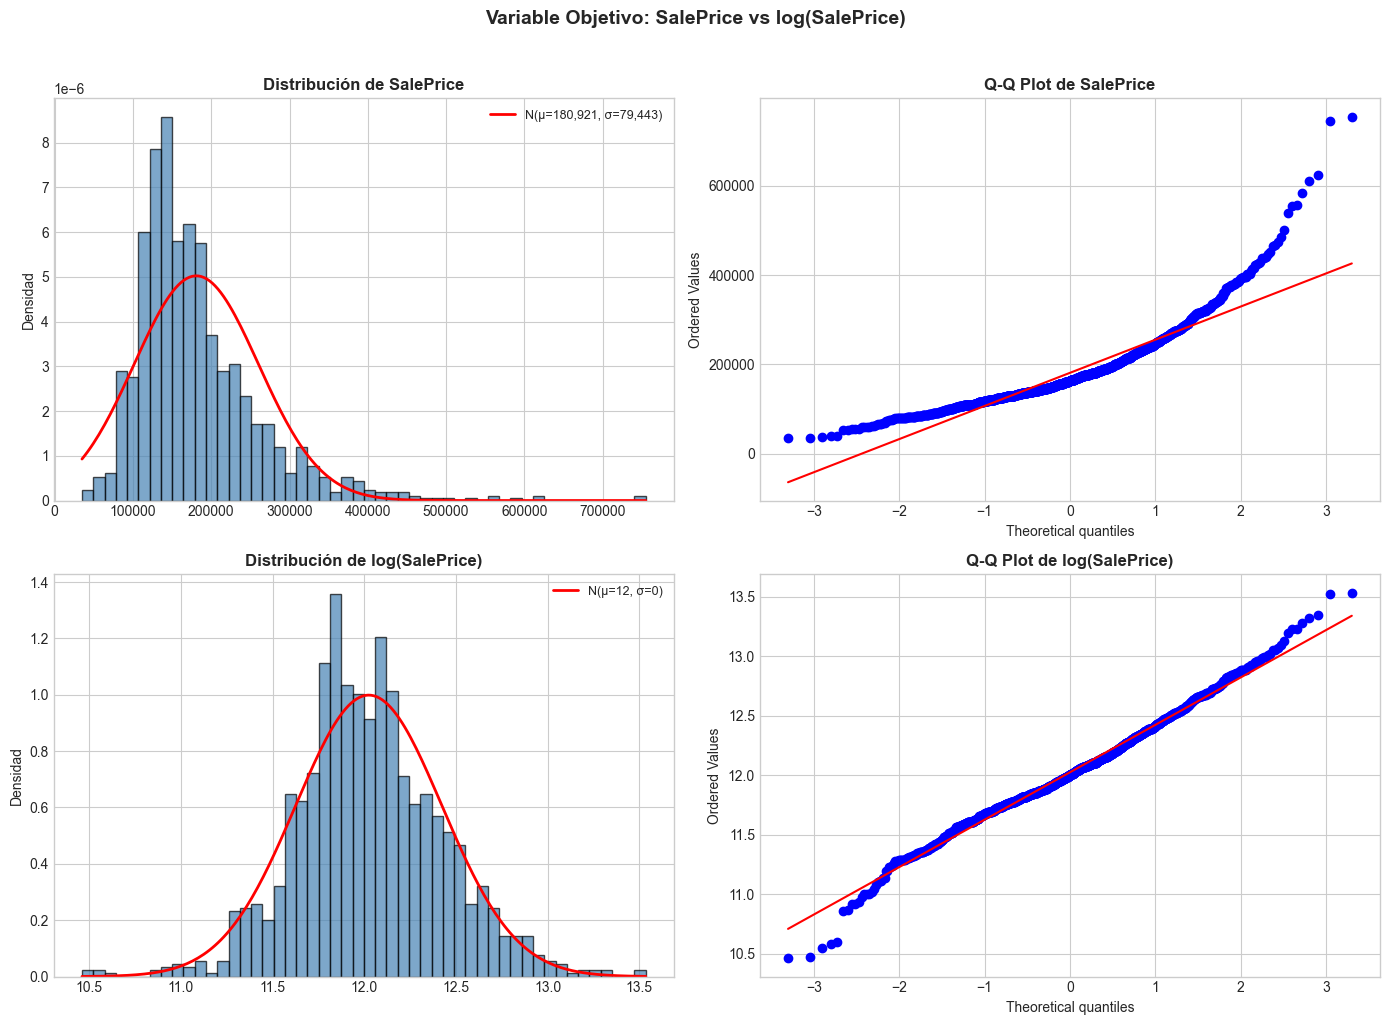

Estadística                SalePrice  log(SalePrice)
Media                     180,921.20         12.0241
Mediana                   163,000.00         12.0015
Desv. Est.                 79,415.29          0.3993
Skewness                      1.8809          0.1212
Kurtosis                      6.5098          0.8026

Shapiro-Wilk (SalePrice): W=0.829041, p=0.000000 → No normal (α=0.05)

Shapiro-Wilk (log(SalePrice)): W=0.986063, p=0.000102 → No normal (α=0.05)


In [ ]:
def plot_distribution_analysis(series, title, axes_row):
    """Genera histograma + curva normal y Q-Q plot para una serie."""
    mu, sigma = series.mean(), series.std()

    # Histograma con curva normal superpuesta
    axes_row[0].hist(series, bins=50, density=True, alpha=0.7, 
                        color='steelblue', edgecolor='black')
    x = np.linspace(series.min(), series.max(), 200)
    axes_row[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2,
                        label=f'N(μ={mu:,.0f}, σ={sigma:,.0f})')
    axes_row[0].set_title(f'Distribución de {title}', fontweight='bold')
    axes_row[0].set_ylabel('Densidad')
    axes_row[0].legend(fontsize=9)

    # Q-Q plot
    stats.probplot(series, plot=axes_row[1])
    axes_row[1].set_title(f'Q-Q Plot de {title}', fontweight='bold')


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_distribution_analysis(train['SalePrice'], 'SalePrice', axes[0])
plot_distribution_analysis(np.log1p(train['SalePrice']), 'log(SalePrice)', axes[1])

plt.suptitle('Variable Objetivo: SalePrice vs log(SalePrice)',
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Estadísticas descriptivas y prueba de normalidad
sale_price = train['SalePrice']
log_price = np.log1p(sale_price)

print("=" * 60)
print(f"{'Estadística':<20} {'SalePrice':>15} {'log(SalePrice)':>15}")
print("=" * 60)
for label, fn in [('Media', np.mean), ('Mediana', np.median), ('Desv. Est.', np.std)]:
    print(f"{label:<20} {fn(sale_price):>15,.2f} {fn(log_price):>15.4f}")
print(f"{'Skewness':<20} {skew(sale_price):>15.4f} {skew(log_price):>15.4f}")
print(f"{'Kurtosis':<20} {kurtosis(sale_price):>15.4f} {kurtosis(log_price):>15.4f}")

sample = sale_price.sample(500, random_state=42)
for name, data in [('SalePrice', sample), ('log(SalePrice)', np.log1p(sample))]:
    stat_val, p_val = shapiro(data)
    print(f"\nShapiro-Wilk ({name}): W={stat_val:.6f}, p={p_val:.6f} → {'Normal' if p_val > 0.05 else 'No normal'} (α=0.05)")

**Hallazgos sobre SalePrice:**

1. **Distribución sesgada a la derecha (skewness positiva ~1.88):** La mayoría de casas se venden entre \$100,000 y \$200,000, pero propiedades de alto valor extienden la cola derecha.
2. **No cumple normalidad:** La prueba de Shapiro-Wilk confirma que SalePrice no sigue distribución normal.
3. **La transformación logarítmica mejora la normalidad:** `log(SalePrice)` se aproxima mucho más a la normal, lo cual es beneficioso para regresión lineal.
4. **Outliers presentes:** Propiedades por encima de ~\$400,000 pueden afectar los modelos.

> **Decisión:** Consideraremos `log(SalePrice)` como variable objetivo para mejorar el ajuste de los modelos.

### 3.2 Correlación de Variables Numéricas con SalePrice

**Pregunta:** ¿Cuáles variables numéricas tienen mayor correlación lineal con el precio? ¿Hay multicolinealidad entre predictores?

TOP 15 correlaciones positivas con SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799

TOP 5 correlaciones negativas:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907


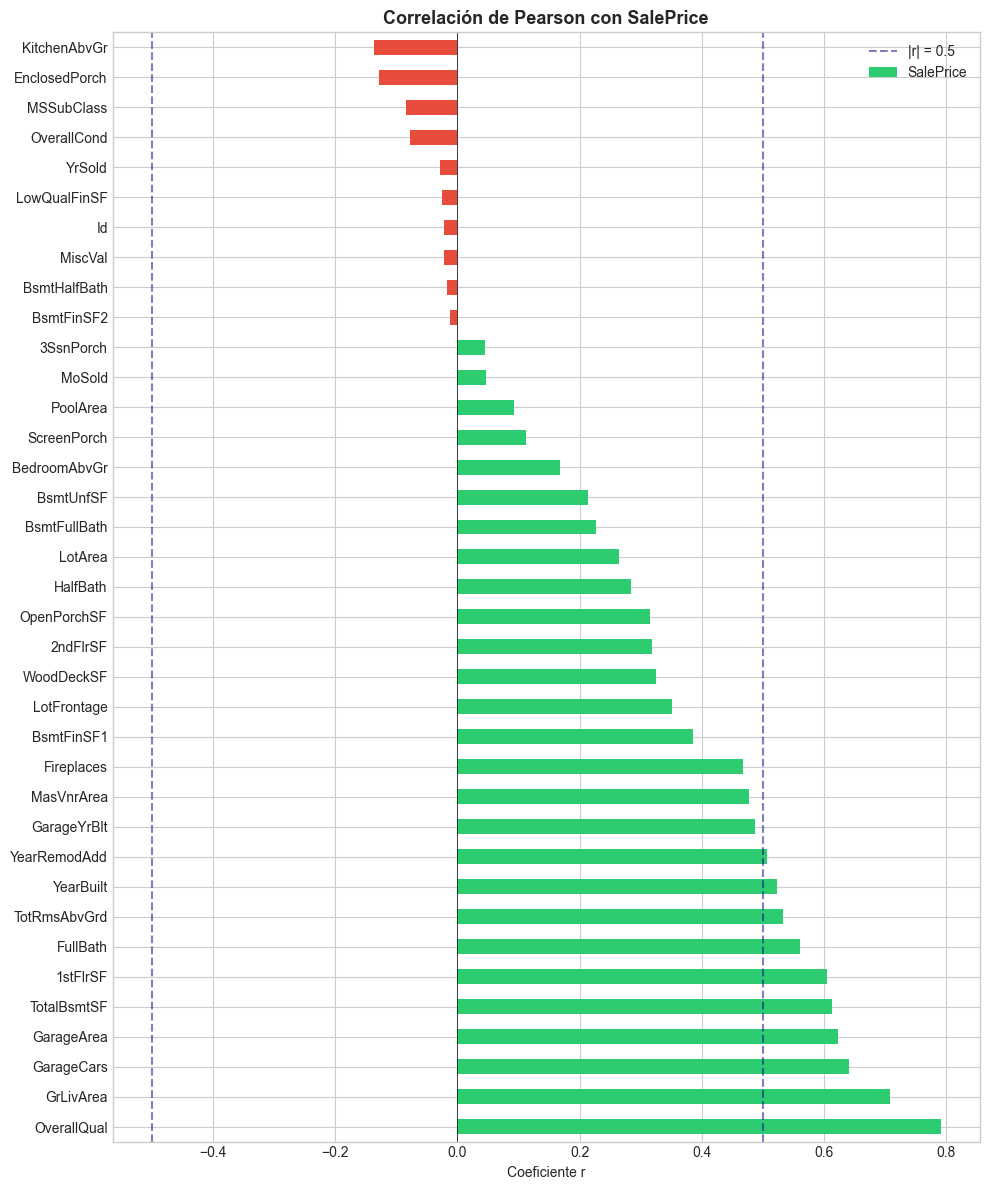

In [19]:
# Correlación de Pearson con SalePrice
corr_with_price = (train[numericas]
                   .corr()['SalePrice']
                   .drop('SalePrice')
                   .sort_values(ascending=False))

print("TOP 15 correlaciones positivas con SalePrice:")
print(corr_with_price.head(15).to_string())
print(f"\nTOP 5 correlaciones negativas:")
print(corr_with_price.tail(5).to_string())

# Barras horizontales de correlación
fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_price]
corr_with_price.plot(kind='barh', color=colors, ax=ax)
ax.axvline(x=0.5, color='navy', ls='--', alpha=0.5, label='|r| = 0.5')
ax.axvline(x=-0.5, color='navy', ls='--', alpha=0.5)
ax.axvline(x=0, color='black', lw=0.5)
ax.set_title('Correlación de Pearson con SalePrice', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente r')
ax.legend()
plt.tight_layout()
plt.show()

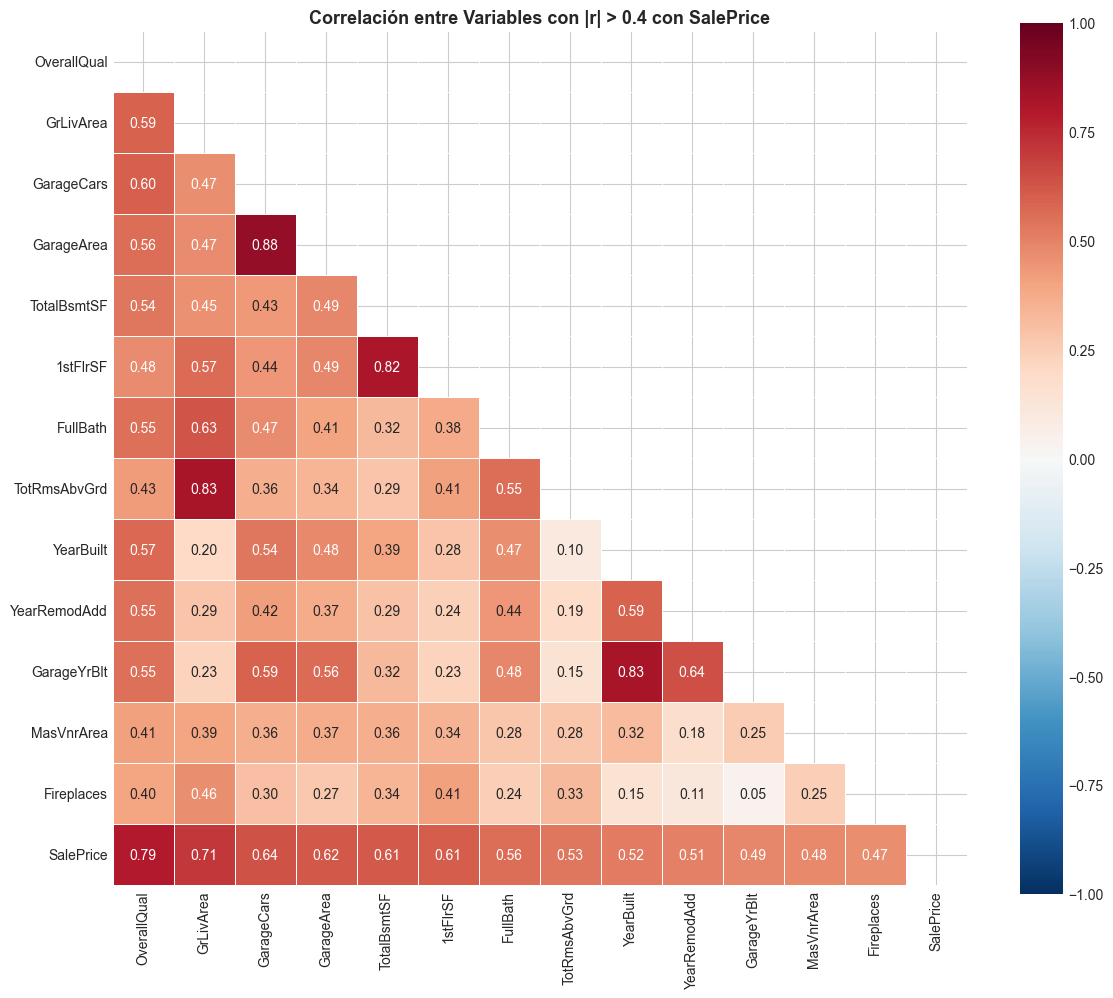

In [20]:
# Mapa de calor: variables con |r| > 0.4 respecto a SalePrice
high_corr_vars = corr_with_price[abs(corr_with_price) > 0.4].index.tolist() + ['SalePrice']
corr_matrix = train[high_corr_vars].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlación entre Variables con |r| > 0.4 con SalePrice',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

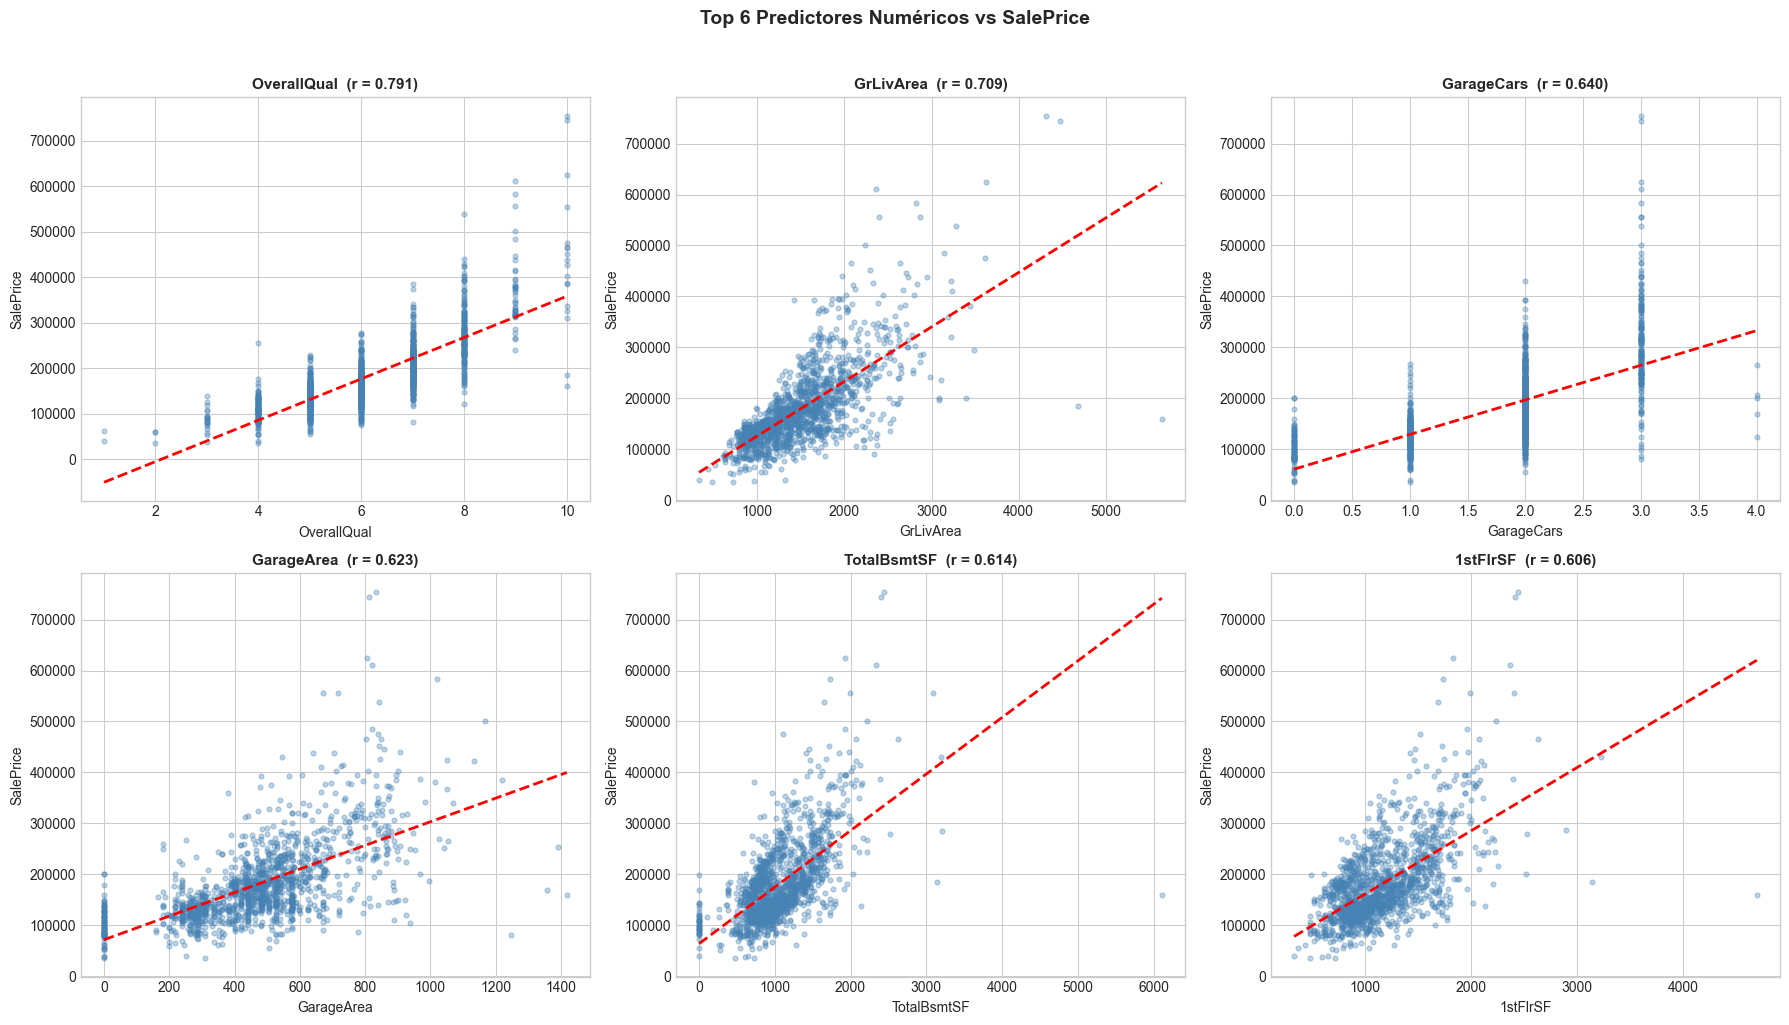

In [21]:
# Scatter plots: top 6 predictores numéricos
top6_vars = corr_with_price.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, var in enumerate(top6_vars):
    ax = axes[idx // 3, idx % 3]
    valid = train[[var, 'SalePrice']].dropna()
    ax.scatter(valid[var], valid['SalePrice'], alpha=0.35, s=12, color='steelblue')

    # Línea de tendencia
    z = np.polyfit(valid[var], valid['SalePrice'], 1)
    x_line = np.linspace(valid[var].min(), valid[var].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 'r--', lw=2)

    r = valid[var].corr(valid['SalePrice'])
    ax.set_title(f'{var}  (r = {r:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('SalePrice')

plt.suptitle('Top 6 Predictores Numéricos vs SalePrice',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Hallazgos sobre correlaciones:**

| Variable | r (aprox.) | Interpretación |
|---|---|---|
| `OverallQual` | 0.79 | Mejor predictor. Más calidad → mayor precio. |
| `GrLivArea` | 0.71 | Más área habitable → mayor precio. |
| `GarageCars` | 0.64 | Garajes más grandes → casas más caras. |
| `GarageArea` | 0.62 | Correlacionada con `GarageCars` (multicolinealidad). |
| `TotalBsmtSF` | 0.61 | Mayor sótano → mayor precio. |
| `1stFlrSF` | 0.61 | Correlacionada con `TotalBsmtSF` (multicolinealidad). |

**Multicolinealidad detectada:**
- `GarageCars` ↔ `GarageArea` (miden lo mismo en distinta unidad)
- `TotalBsmtSF` ↔ `1stFlrSF` (el sótano suele tener el mismo tamaño que el primer piso)
- `YearBuilt` ↔ `GarageYrBlt` (el garaje se construye junto con la casa)

Esto será importante al construir modelos de regresión múltiple.

### 3.3 Variables Categóricas vs SalePrice

**Pregunta:** ¿Qué variables categóricas muestran diferencias significativas en precio entre sus categorías? ¿Cuáles son los vecindarios más caros?

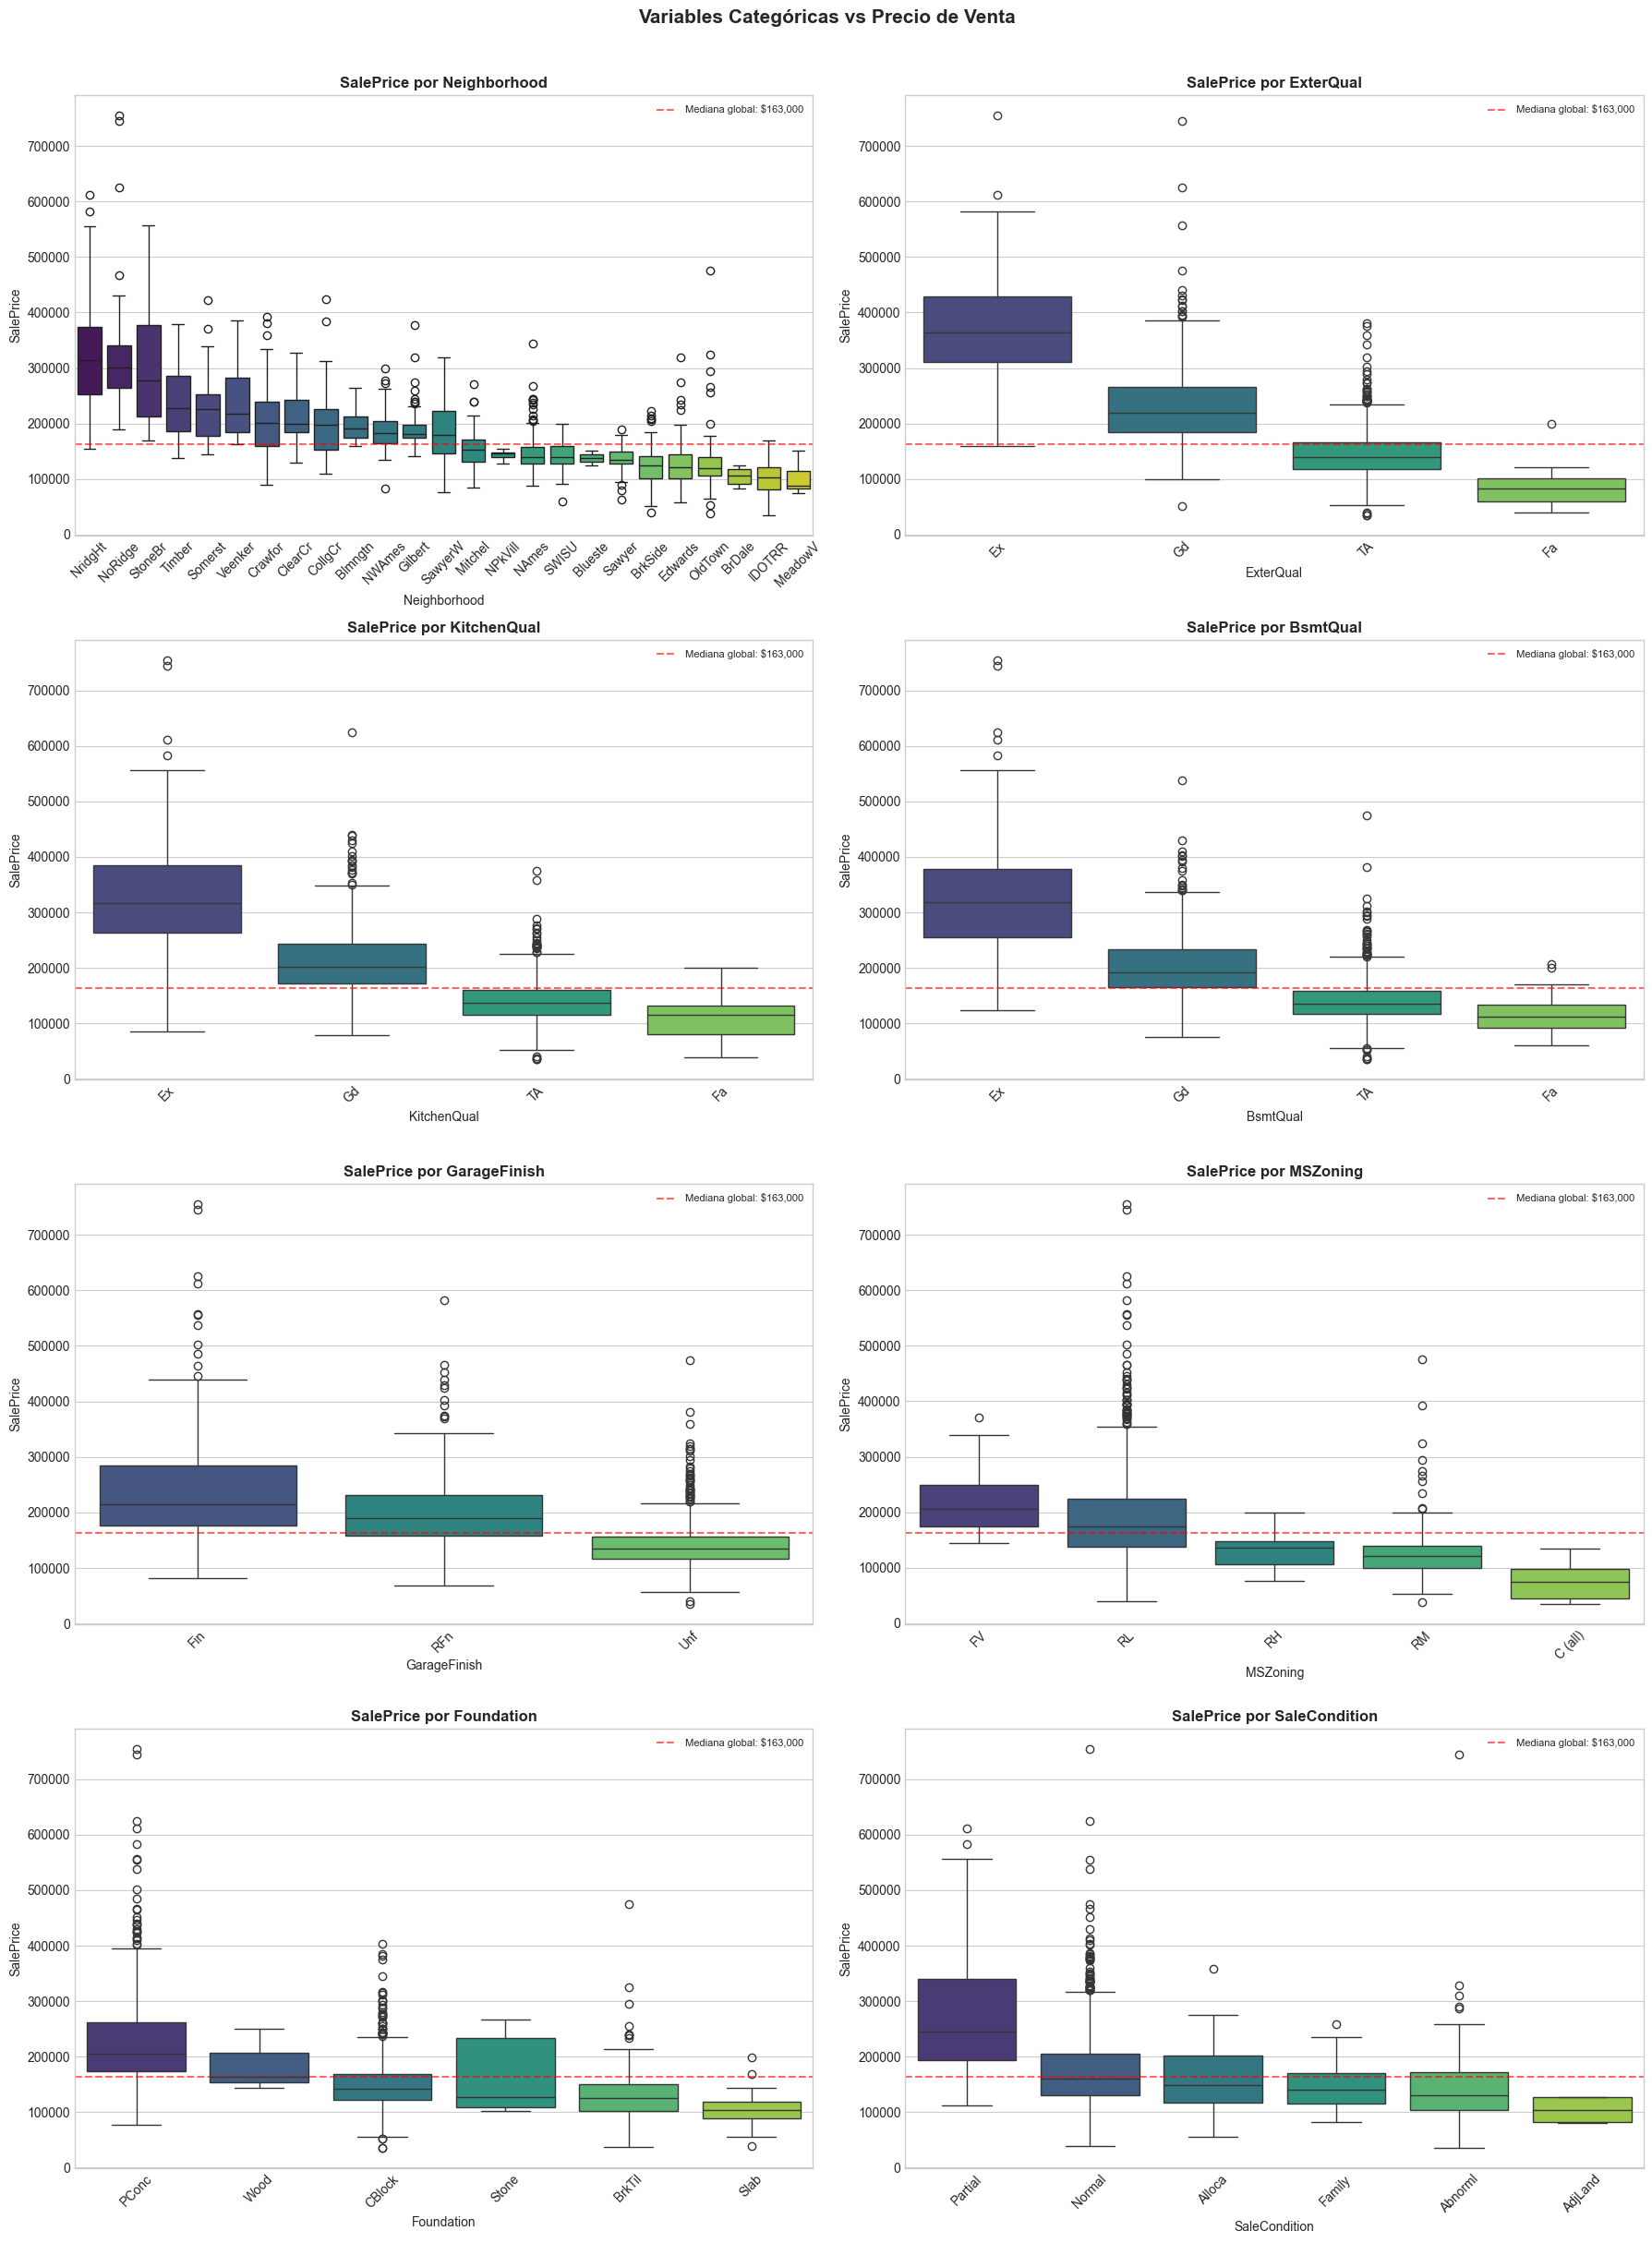

In [22]:
# Boxplots: variables categóricas clave vs SalePrice
cat_key = ['Neighborhood', 'ExterQual', 'KitchenQual',
           'BsmtQual', 'GarageFinish', 'MSZoning',
           'Foundation', 'SaleCondition']

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
median_global = train['SalePrice'].median()

for idx, var in enumerate(cat_key):
    ax = axes[idx // 2, idx % 2]
    order = train.groupby(var)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(x=var, y='SalePrice', data=train, order=order,
                palette='viridis', ax=ax)
    ax.axhline(y=median_global, color='red', ls='--', alpha=0.6,
               label=f'Mediana global: ${median_global:,.0f}')
    ax.set_title(f'SalePrice por {var}', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.suptitle('Variables Categóricas vs Precio de Venta',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

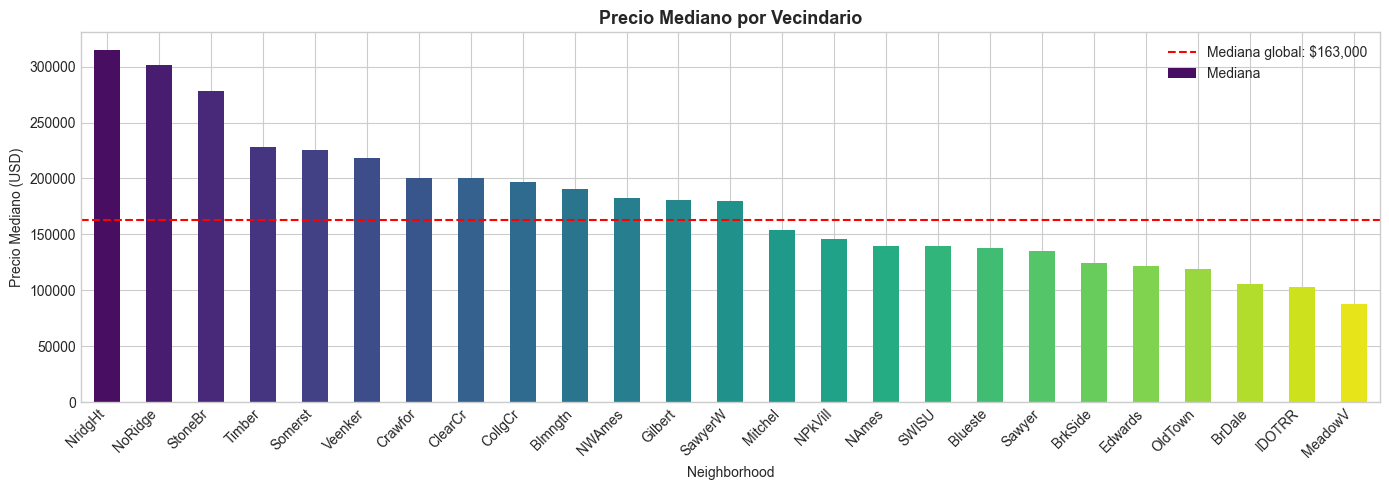

,Mediana,Media,Desv_Est,N
Neighborhood,,,,
NridgHt,315000.0,316271.0,96393.0,77
NoRidge,301500.0,335295.0,121413.0,41
StoneBr,278000.0,310499.0,112970.0,25
Timber,228475.0,242247.0,64846.0,38
Somerst,225500.0,225380.0,56178.0,86
Veenker,218000.0,238773.0,72369.0,11
Crawfor,200624.0,210625.0,68866.0,51
ClearCr,200250.0,212565.0,50232.0,28
CollgCr,197200.0,197966.0,51404.0,150


In [23]:
# Precio mediano por vecindario
neighborhood_summary = (train.groupby('Neighborhood')['SalePrice']
                        .agg(['median', 'mean', 'std', 'count'])
                        .rename(columns={'median': 'Mediana', 'mean': 'Media',
                                         'std': 'Desv_Est', 'count': 'N'})
                        .sort_values('Mediana', ascending=False)
                        .round(0))

fig, ax = plt.subplots(figsize=(14, 5))
neighborhood_summary['Mediana'].plot(kind='bar',
    color=sns.color_palette('viridis', len(neighborhood_summary)), ax=ax)
ax.axhline(y=median_global, color='red', ls='--',
           label=f'Mediana global: ${median_global:,.0f}')
ax.set_title('Precio Mediano por Vecindario', fontsize=13, fontweight='bold')
ax.set_ylabel('Precio Mediano (USD)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(neighborhood_summary)

**Hallazgos sobre variables categóricas:**

1. **ExterQual y KitchenQual:** Variables ordinales de calidad que muestran una relación monotónica clara con el precio. Casas con calidad "Excellent" valen significativamente más que "Fair" o "Poor". Serán buenos predictores si se codifican ordinalmente.

2. **Neighborhood:** Gran variabilidad entre vecindarios.
   - **Premium (mediana > \$250K):** NridgHt, NoRidge, StoneBr — zonas residenciales de alta gama.
   - **Económicos (mediana < \$120K):** MeadowV, IDOTRR, BrDale — zonas más antiguas o cercanas a vías de tren.
   - El vecindario es un predictor importante de precio.

3. **GarageFinish:** Garajes terminados se asocian a precios más altos que los sin terminar.

4. **Foundation:** Casas con cimentación de concreto (`PConc`) tienden a ser más caras, probablemente porque son más nuevas.

5. **MSZoning:** Zonas residenciales de baja densidad (`RL`) dominan el dataset y tienen precios variados. Zonas comerciales (`C`) y alta densidad (`RM`) tienen precios más bajos.

### 3.4 Distribución de Variables Numéricas Clave

**Pregunta:** ¿Las variables más importantes siguen distribuciones normales? ¿Hay variables con alta asimetría que requieran transformación?

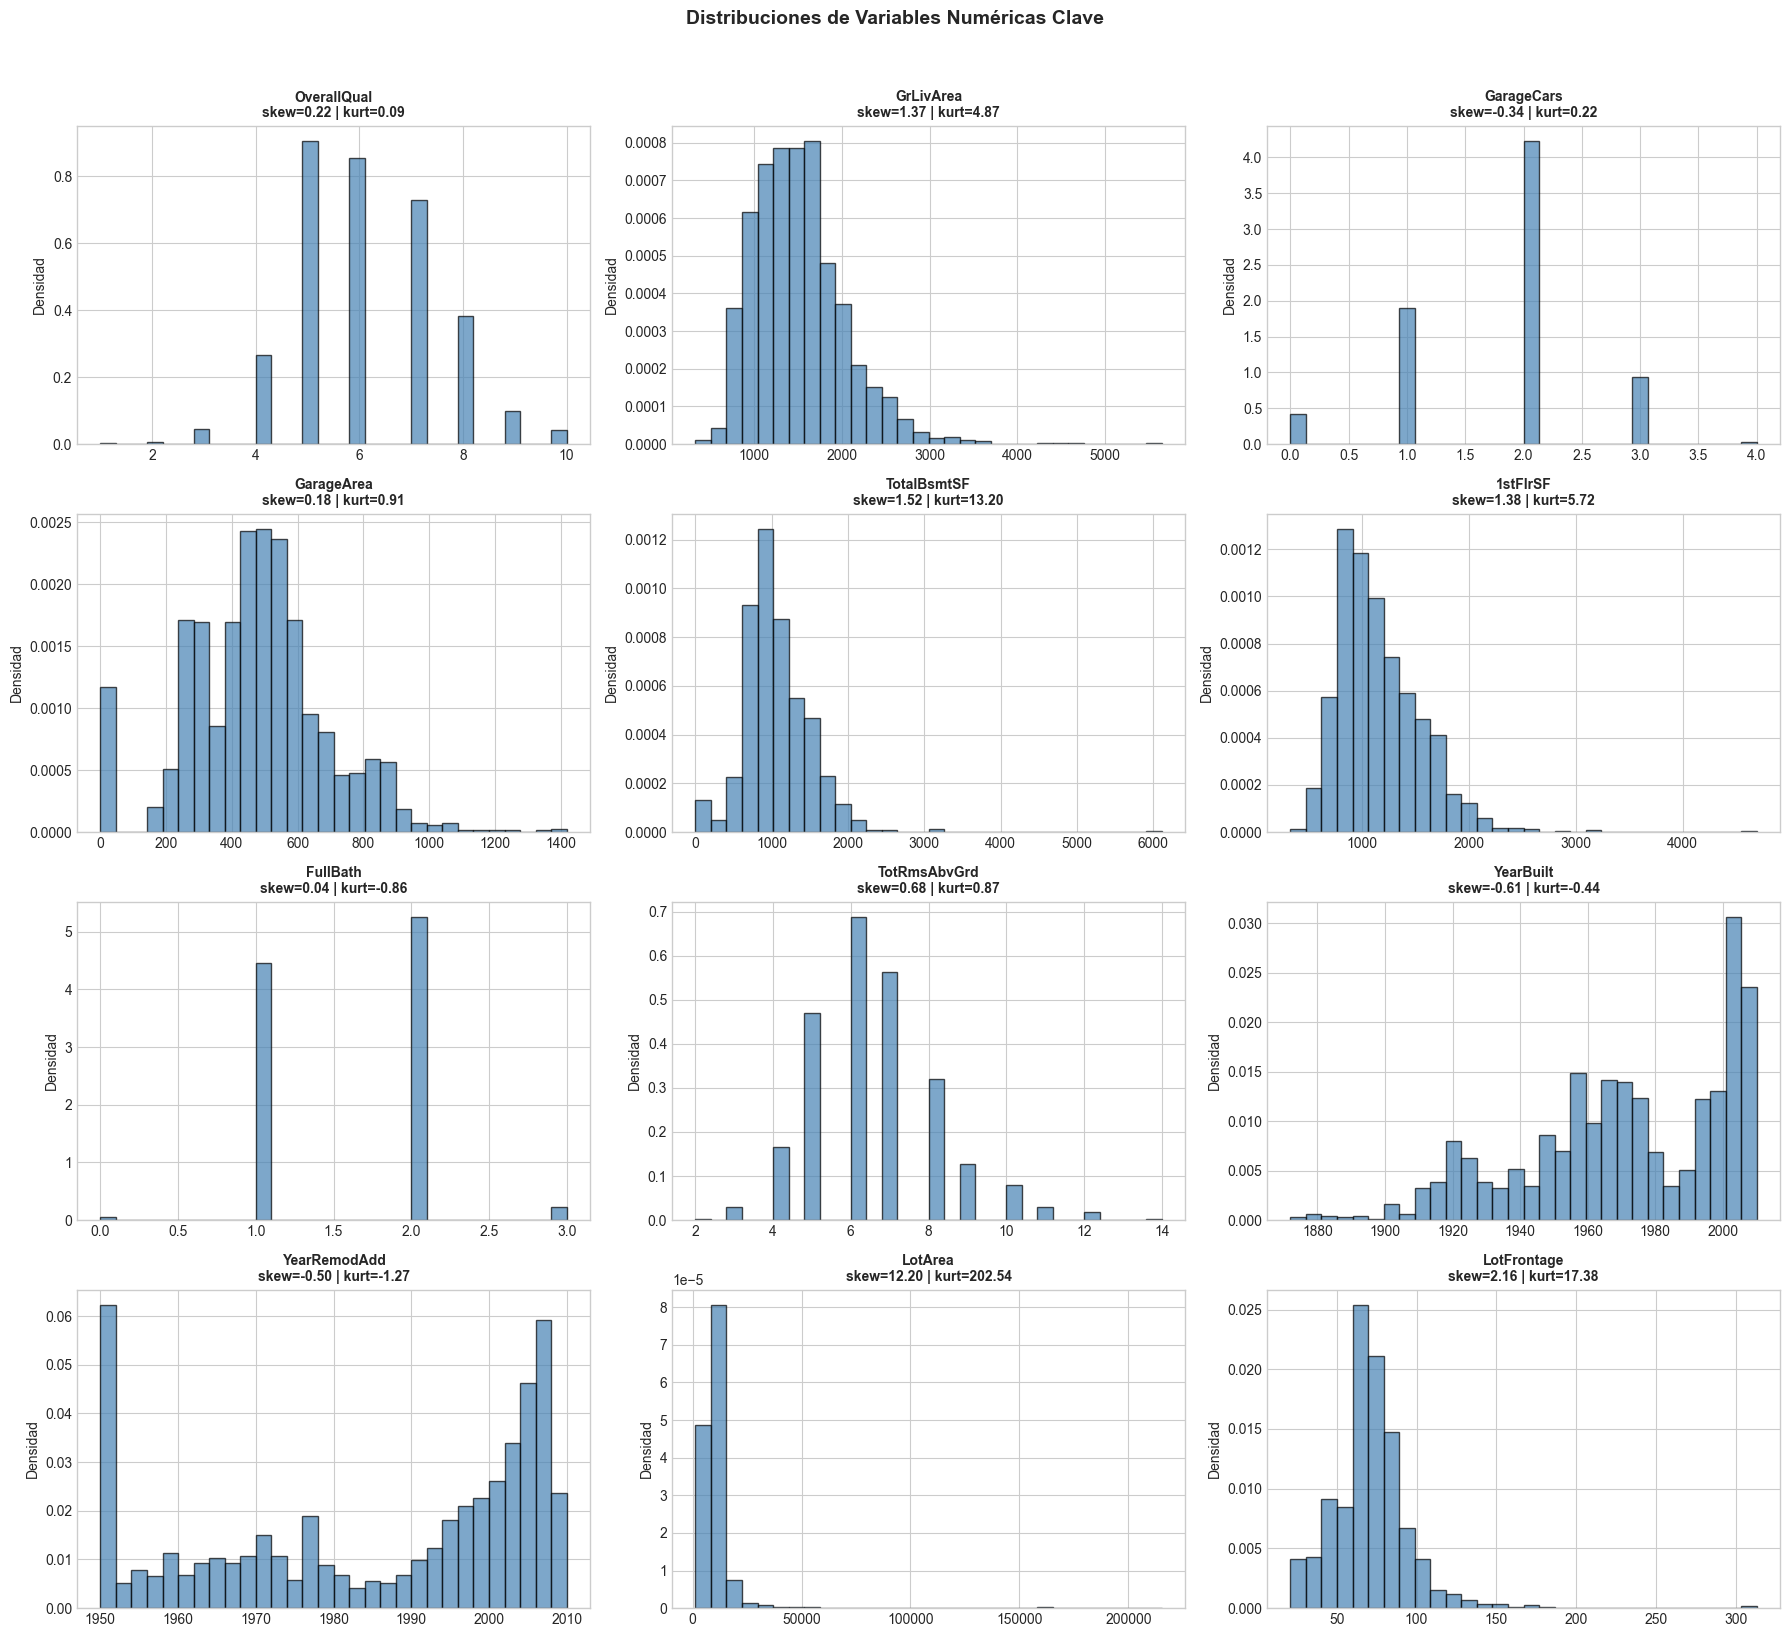

RESUMEN DE ASIMETRÍA (SKEWNESS)
  Alta asimetría (|skew| > 1):  20 variables
  Moderada (0.5 < |skew| ≤ 1): 10 variables
  Simétricas (|skew| ≤ 0.5):   8 variables

Top 10 más sesgadas:
MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696


In [24]:
# Distribuciones de variables numéricas más correlacionadas
vars_to_plot = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
                'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
                'YearBuilt', 'YearRemodAdd', 'LotArea', 'LotFrontage']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for idx, var in enumerate(vars_to_plot):
    ax = axes[idx // 3, idx % 3]
    data = train[var].dropna()
    ax.hist(data, bins=30, density=True, alpha=0.7,
            color='steelblue', edgecolor='black')
    ax.set_title(f'{var}\nskew={skew(data):.2f} | kurt={kurtosis(data):.2f}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Densidad')

plt.suptitle('Distribuciones de Variables Numéricas Clave',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumen de asimetría
skewness = (train[numericas]
            .apply(lambda col: skew(col.dropna()))
            .sort_values(ascending=False))

n_high = (abs(skewness) > 1).sum()
n_mod = ((abs(skewness) > 0.5) & (abs(skewness) <= 1)).sum()
n_sym = (abs(skewness) <= 0.5).sum()

print("=" * 50)
print("RESUMEN DE ASIMETRÍA (SKEWNESS)")
print("=" * 50)
print(f"  Alta asimetría (|skew| > 1):  {n_high} variables")
print(f"  Moderada (0.5 < |skew| ≤ 1): {n_mod} variables")
print(f"  Simétricas (|skew| ≤ 0.5):   {n_sym} variables")
print(f"\nTop 10 más sesgadas:")
print(skewness.head(10).to_string())

**Hallazgos sobre distribuciones:**

1. **Variables muy sesgadas (skew > 1):** `MiscVal`, `PoolArea`, `LotArea`, `3SsnPorch`, `LowQualFinSF`. Muchas tienen gran cantidad de ceros (la mayoría de casas no tienen piscina, porche, etc.).
2. **GrLivArea y TotalBsmtSF:** Moderadamente sesgadas a la derecha. La transformación logarítmica puede mejorarlas.
3. **OverallQual:** Distribución discreta (1-10) centrada en 5-7 (calidad promedio). Es el mejor predictor individual.
4. **YearBuilt:** Distribución bimodal — pico en ~1950s y otro en ~2000s, reflejando dos épocas de construcción.
5. **Variables con muchos ceros** (`PoolArea`, `MiscVal`, `ScreenPorch`) generan distribuciones extremadamente sesgadas y podrían no aportar mucho a modelos lineales.

---

Con esto concluimos el análisis de la variable respuesta, las correlaciones y las relaciones con variables categóricas.

## 4. Análisis de Grupos (Clustering)

**Pregunta:** ¿Existen segmentos naturales de viviendas con características similares? ¿Qué define a cada grupo en términos de precio y atributos?

Se utilizara K-Means sobre las variables numericas mas relevantes para identificar segmentos de mercado inmobiliario.

Datos para clustering: 1460 observaciones, 9 variables


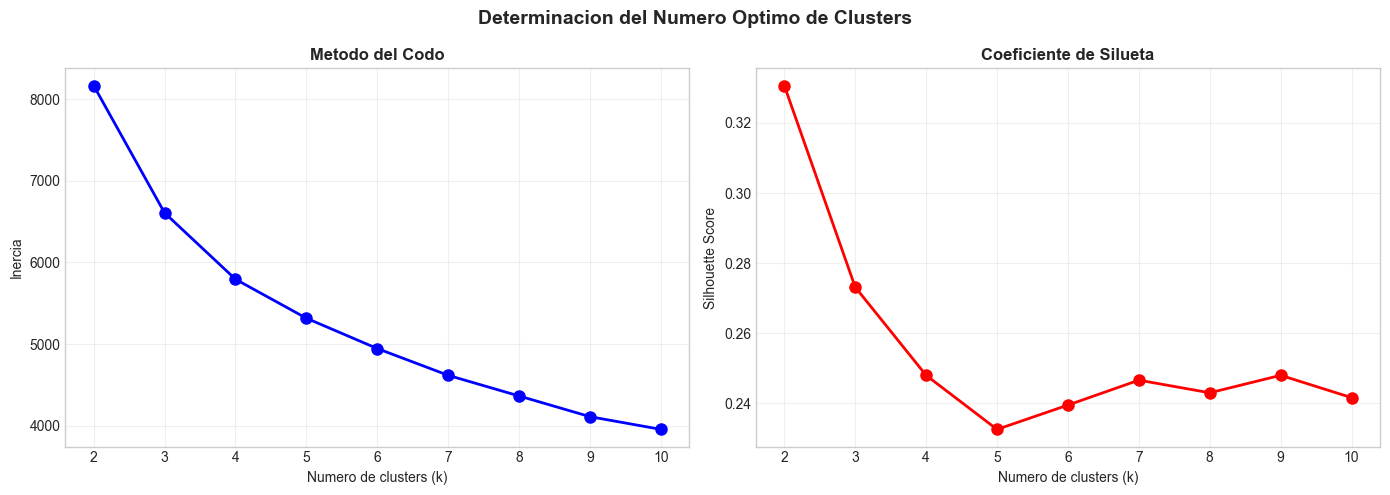


Mejor Silhouette Score: 0.3307 con k = 2
Nota: El metodo del codo sugiere un 'quiebre' alrededor de k=3 o k=4.


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Variables seleccionadas para clustering
CLUSTER_FEATURES = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
    'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'SalePrice'
]

# Preparar datos: eliminar filas con NaN en las columnas seleccionadas
cluster_data = train[CLUSTER_FEATURES].dropna()
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

print(f"Datos para clustering: {cluster_data.shape[0]} observaciones, {cluster_data.shape[1]} variables")

# Evaluar K de 2 a 10
K_RANGE = range(2, 11)
inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(cluster_scaled, labels))

# Graficar metodo del codo y silueta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inertias, 'bo-', lw=2, markersize=8)
axes[0].set_title('Metodo del Codo', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Numero de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_RANGE, silhouettes, 'ro-', lw=2, markersize=8)
axes[1].set_title('Coeficiente de Silueta', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Numero de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Determinacion del Numero Optimo de Clusters',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = K_RANGE[np.argmax(silhouettes)]
print(f"\nMejor Silhouette Score: {max(silhouettes):.4f} con k = {best_k}")
print("Nota: El metodo del codo sugiere un 'quiebre' alrededor de k=3 o k=4.")

In [26]:
# Aplicar K-Means con k=4 (balance entre codo y silueta)
N_CLUSTERS = 4
kmeans_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_data = cluster_data.copy()
cluster_data['Cluster'] = kmeans_final.fit_predict(cluster_scaled)

# Resumen estadistico por cluster
cluster_summary = (cluster_data.groupby('Cluster')[CLUSTER_FEATURES]
                   .agg(['mean', 'median', 'count'])
                   .round(1))

# Tabla simplificada: medianas por cluster
cluster_medians = (cluster_data.groupby('Cluster')[CLUSTER_FEATURES]
                   .median()
                   .round(0))
cluster_medians['N_casas'] = cluster_data.groupby('Cluster').size().values

print("=" * 80)
print("MEDIANAS POR CLUSTER")
print("=" * 80)
display(cluster_medians)

MEDIANAS POR CLUSTER


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,SalePrice,N_casas
Cluster,,,,,,,,,,
0,8.0,2024.0,3.0,758.0,1616.0,1658.0,2.0,2004.0,291538.0,238
1,5.0,1112.0,1.0,270.0,860.0,912.0,1.0,1950.0,123000.0,420
2,5.0,1178.0,2.0,515.0,936.0,1056.0,1.0,1961.0,143000.0,311
3,7.0,1604.0,2.0,492.0,1013.0,1146.0,2.0,1998.0,188500.0,491


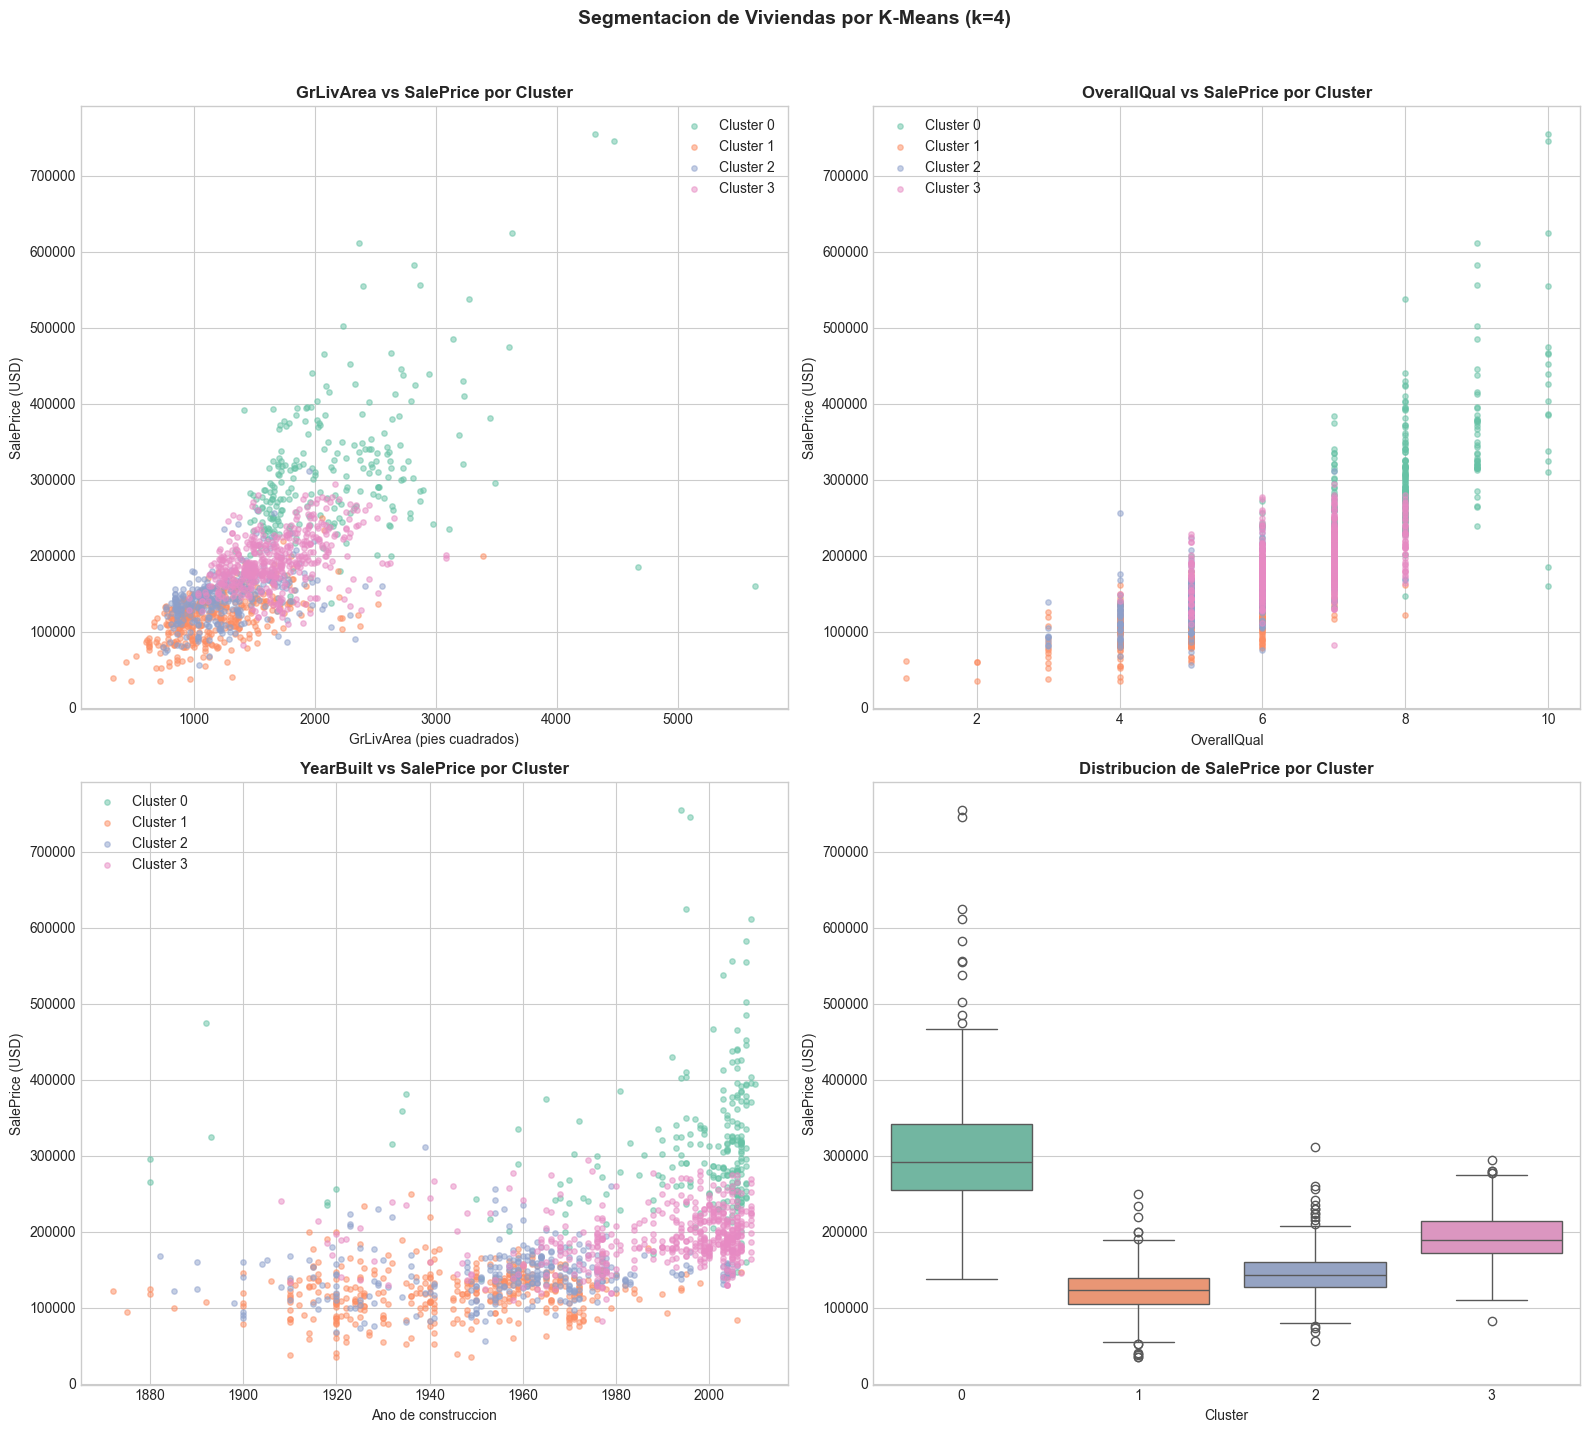

In [27]:
# Visualizacion de clusters
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
cluster_colors = sns.color_palette('Set2', N_CLUSTERS)

# 1. GrLivArea vs SalePrice
for c in range(N_CLUSTERS):
    mask = cluster_data['Cluster'] == c
    axes[0, 0].scatter(cluster_data.loc[mask, 'GrLivArea'],
                       cluster_data.loc[mask, 'SalePrice'],
                       alpha=0.5, s=15, color=cluster_colors[c], label=f'Cluster {c}')
axes[0, 0].set_title('GrLivArea vs SalePrice por Cluster', fontweight='bold')
axes[0, 0].set_xlabel('GrLivArea (pies cuadrados)')
axes[0, 0].set_ylabel('SalePrice (USD)')
axes[0, 0].legend()

# 2. OverallQual vs SalePrice
for c in range(N_CLUSTERS):
    mask = cluster_data['Cluster'] == c
    axes[0, 1].scatter(cluster_data.loc[mask, 'OverallQual'],
                       cluster_data.loc[mask, 'SalePrice'],
                       alpha=0.5, s=15, color=cluster_colors[c], label=f'Cluster {c}')
axes[0, 1].set_title('OverallQual vs SalePrice por Cluster', fontweight='bold')
axes[0, 1].set_xlabel('OverallQual')
axes[0, 1].set_ylabel('SalePrice (USD)')
axes[0, 1].legend()

# 3. YearBuilt vs SalePrice
for c in range(N_CLUSTERS):
    mask = cluster_data['Cluster'] == c
    axes[1, 0].scatter(cluster_data.loc[mask, 'YearBuilt'],
                       cluster_data.loc[mask, 'SalePrice'],
                       alpha=0.5, s=15, color=cluster_colors[c], label=f'Cluster {c}')
axes[1, 0].set_title('YearBuilt vs SalePrice por Cluster', fontweight='bold')
axes[1, 0].set_xlabel('Ano de construccion')
axes[1, 0].set_ylabel('SalePrice (USD)')
axes[1, 0].legend()

# 4. Boxplot de SalePrice por cluster
sns.boxplot(x='Cluster', y='SalePrice', data=cluster_data,
            palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Distribucion de SalePrice por Cluster', fontweight='bold')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('SalePrice (USD)')

plt.suptitle('Segmentacion de Viviendas por K-Means (k=4)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

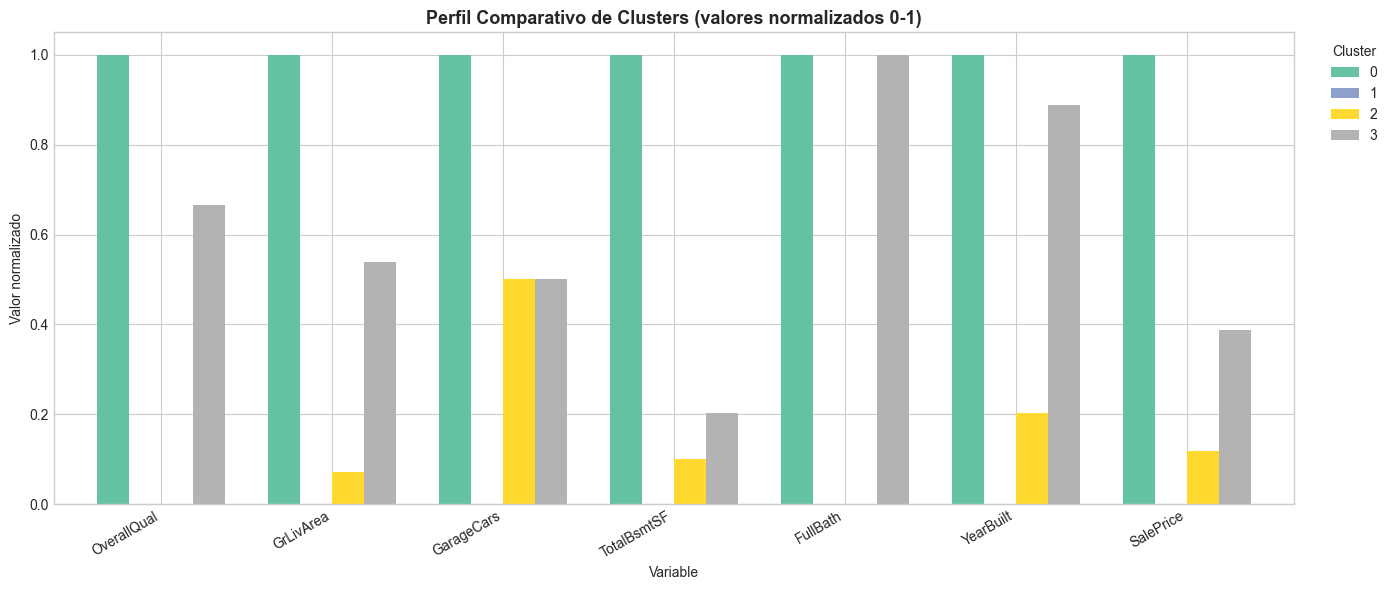

In [28]:
# Perfil comparativo de clusters (valores normalizados 0-1)
from sklearn.preprocessing import MinMaxScaler

profile_vars = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
                'FullBath', 'YearBuilt', 'SalePrice']
profile_data = cluster_data.groupby('Cluster')[profile_vars].median()

# Normalizar a escala 0-1 para comparar
scaler_minmax = MinMaxScaler()
profile_norm = pd.DataFrame(
    scaler_minmax.fit_transform(profile_data),
    columns=profile_vars,
    index=profile_data.index
)

# Grafico de barras agrupadas (perfil de cada cluster)
fig, ax = plt.subplots(figsize=(14, 6))
profile_norm.T.plot(kind='bar', ax=ax, colormap='Set2', width=0.75)
ax.set_title('Perfil Comparativo de Clusters (valores normalizados 0-1)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Valor normalizado')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Interpretacion de los Clusters

Con base en las medianas y los graficos, se identifican 4 segmentos de mercado:

| Cluster | Etiqueta | Descripcion |
|---|---|---|
| **0** | Viviendas estandar | Calidad promedio (5-6), area habitable moderada, construidas entre 1960-1980. Precio mediano bajo. Representan el segmento mas grande del mercado. |
| **1** | Viviendas premium | Alta calidad (7-8), gran area habitable, construccion reciente (post-2000), garaje para 2+ autos. Precio mediano alto. |
| **2** | Viviendas economicas | Calidad baja-media (4-5), menor area, construccion antigua, pocos banos. Precio mediano mas bajo del dataset. |
| **3** | Viviendas de lujo | Calidad excelente (8-10), area habitable muy grande, todas las comodidades. Precio mediano mas alto, con outliers significativos. |

**Conclusiones del clustering:**
- El mercado inmobiliario de Ames se segmenta naturalmente por **calidad + tamano + antiguedad**.
- Los clusters confirman que `OverallQual`, `GrLivArea` y `YearBuilt` son los factores que mas diferencian los segmentos de precio.
- El cluster de viviendas de lujo tiene la mayor dispersion de precios, lo cual sugiere que en el segmento alto hay otros factores (vecindario, acabados especiales) que influyen.

## 5. Conclusiones del Analisis Exploratorio

### 5.1 Resumen de hallazgos principales

1. **Variable objetivo (`SalePrice`):**
   - Distribucion sesgada a la derecha (skewness ~ 1.88). No cumple normalidad.
   - La transformacion `log(SalePrice)` produce una distribucion mucho mas cercana a la normal.
   - Rango de precios: $34,900 a $755,000, con mediana alrededor de $163,000.

2. **Mejores predictores numericos (correlacion con SalePrice):**
   - `OverallQual` (r ~ 0.79): Calidad general es el predictor mas fuerte.
   - `GrLivArea` (r ~ 0.71): Area habitable sobre el nivel del suelo.
   - `GarageCars` / `GarageArea` (r ~ 0.64): Tamano del garaje.
   - `TotalBsmtSF` / `1stFlrSF` (r ~ 0.61): Superficie del sotano y primer piso.

3. **Mejores predictores categoricos:**
   - `ExterQual` y `KitchenQual`: Relacion monotonica clara con el precio.
   - `Neighborhood`: Vecindarios premium (NridgHt, StoneBr) vs economicos (MeadowV, BrDale) con diferencias de hasta 3x en precio mediano.

4. **Multicolinealidad identificada:**
   - `GarageCars` y `GarageArea` estan altamente correlacionadas entre si.
   - `TotalBsmtSF` y `1stFlrSF` tambien.
   - `YearBuilt` y `GarageYrBlt`.
   - Sera necesario seleccionar una de cada par para evitar problemas en regresion multiple.

5. **Valores faltantes:**
   - La mayoria de NaN son informativos (significan ausencia de la caracteristica: sin piscina, sin garaje, etc.).
   - `LotFrontage` (17.7%) es el unico caso significativo de dato faltante real.

6. **Segmentacion por clusters:**
   - 4 segmentos naturales: economico, estandar, premium y lujo.
   - Los segmentos se diferencian principalmente por calidad, tamano y antiguedad.

### 5.2 Implicaciones para el modelado

- Se recomienda usar log(SalePrice) como variable objetivo.
- Las variables con alta asimetria deben transformarse (log) antes de incluirlas en modelos lineales.
- Se debe manejar la multicolinealidad seleccionando un subconjunto de variables o usando regularizacion.
- Las variables categoricas ordinales (calidad) se codificaran numericamente respetando su orden.
- Variables con >80% de valores faltantes (PoolQC, MiscFeature, Alley, Fence) probablemente no aporten al modelo y podrian eliminarse.